In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
from itertools import combinations
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA
import statsmodels
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import pmdarima as pm

pd.options.display.float_format = '{:.2f}'.format


Optional HW7:

данные - https://www.kaggle.com/datasets/neuromusic/avocado-prices

Аггрегировать как сумма по date для колонок [Total Volume, date]: date - sum(Total Volume) Чтобы посчитать по всем городам сразу

повторить

подобрать оптимальное значения для SARIMA для сл. датасета

Сделать лучшее предсказание по метрикам R2, RMSE

In [7]:
import os
os.system("kaggle datasets download -d neuromusic/avocado-prices -p /Users/tolkyn.zhagipar/Desktop/outpeer/Module8 --unzip")

Dataset URL: https://www.kaggle.com/datasets/neuromusic/avocado-prices
License(s): ODbL-1.0


  0%|          | 0.00/629k [00:00<?, ?B/s]

100%|██████████| 629k/629k [00:00<00:00, 644kB/s]


0

In [9]:
print(os.listdir("/Users/tolkyn.zhagipar/Desktop/outpeer/Module8"))

['AirPassengers.csv', '.DS_Store', 'avocado.csv', 'archive (1).zip']


In [10]:
data = pd.read_csv("/Users/tolkyn.zhagipar/Desktop/outpeer/Module8/avocado.csv")

In [14]:
# size = int(len(data) - 30)
# train, test = data['Unnamed: 0'][0:size], data['Unnamed: 0'][size:len(data)]

In [16]:
data = data.drop(columns = ['Unnamed: 0'])
data.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.00,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.00,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.00,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.00,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.00,conventional,2015,Albany


In [18]:
data.shape

(18249, 13)

In [20]:
data.columns

Index(['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region'],
      dtype='object')

In [22]:
#data = data.drop(columns = ['Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags'])

In [24]:
data.isna().sum()

Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [26]:
data.describe()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00
mean,1.41,850644.01,293008.42,295154.57,22839.74,239639.20,182194.69,54338.09,3106.43,2016.15
std,0.40,3453545.36,1264989.08,1204120.40,107464.07,986242.40,746178.51,243965.96,17692.89,0.94
min,0.44,84.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2015.00
25%,1.10,10838.58,854.07,3008.78,0.00,5088.64,2849.42,127.47,0.00,2015.00
50%,1.37,107376.76,8645.30,29061.02,184.99,39743.83,26362.82,2647.71,0.00,2016.00
75%,1.66,432962.29,111020.20,150206.86,6243.42,110783.37,83337.67,22029.25,132.50,2017.00
max,3.25,62505646.52,22743616.17,20470572.61,2546439.11,19373134.37,13384586.80,5719096.61,551693.65,2018.00


In [28]:
data.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.00,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.00,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.00,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.00,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.00,conventional,2015,Albany


In [30]:
data.tail()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.00,organic,2018,WestTexNewMexico
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.00,organic,2018,WestTexNewMexico
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.00,organic,2018,WestTexNewMexico
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.00,organic,2018,WestTexNewMexico
18248,2018-01-07,1.62,17489.58,2894.77,2356.13,224.53,12014.15,11988.14,26.01,0.00,organic,2018,WestTexNewMexico


In [32]:
# First step
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

data_volume = data.groupby('Date')['Total Volume'].sum().reset_index()

data_volume.set_index('Date', inplace=True)

In [34]:
data_volume.head(n=10)

,Total Volume
Date,
2015-01-04,84674337.20
2015-01-11,78555807.24
2015-01-18,78388784.08
2015-01-25,76466281.07
2015-02-01,119453235.25
2015-02-08,86671106.20
2015-02-15,75637163.03
2015-02-22,80876094.75
2015-03-01,89434843.26


In [36]:
# Second step, repeat aggregation for months
df_monthly = data_volume.resample("ME").sum().reset_index()
df_monthly.head()

,Date,Total Volume
0,2015-01-31,318085209.59
1,2015-02-28,362637599.23
2,2015-03-31,418583069.77
3,2015-04-30,344144395.15
4,2015-05-31,483784044.79


Text(0, 0.5, 'Frequency')

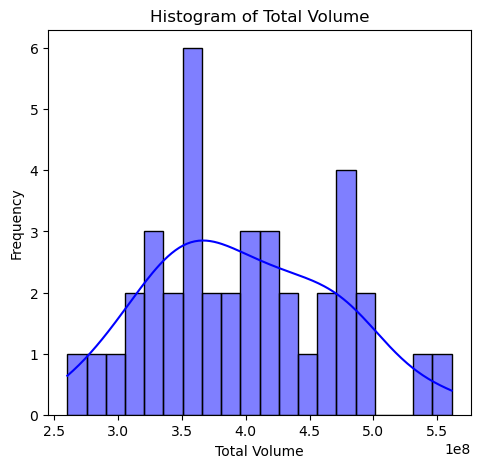

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms
plt.figure(figsize=(12, 5))

# Original Data
plt.subplot(1, 2, 1)
sns.histplot(df_monthly["Total Volume"], bins=20, kde=True, color="blue")
plt.title("Histogram of Total Volume")
plt.xlabel("Total Volume")
plt.ylabel("Frequency")


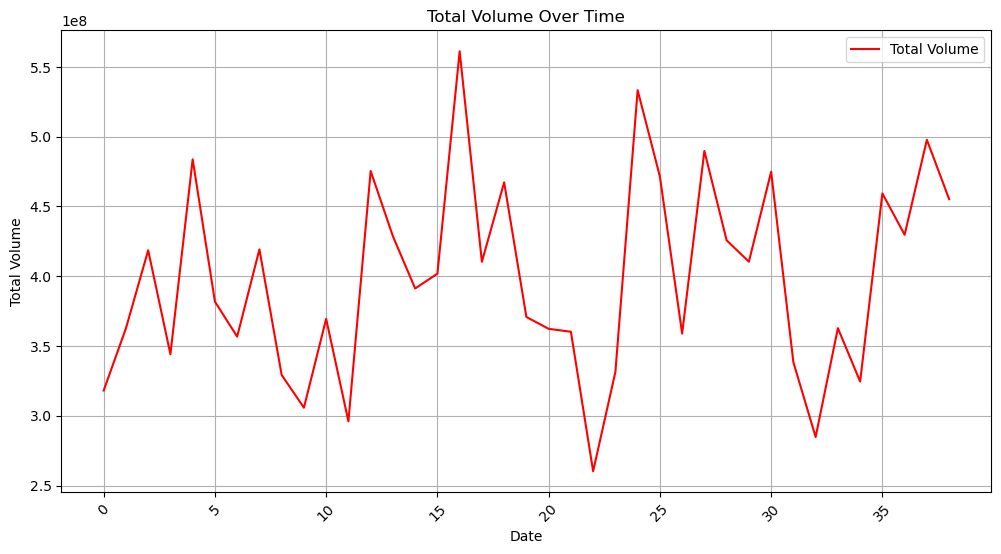

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(df_monthly["Total Volume"], label="Total Volume", color="red")

plt.xlabel("Date")
plt.ylabel("Total Volume")
plt.title("Total Volume Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [42]:
def test_stationarity(timeseries, window):
    #Determing rolling statistics
    MA = timeseries.rolling(window=window).mean()
    MSTD = timeseries.rolling(window=window).std()

    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(MA, color='red', label='Rolling Mean')
    std = plt.plot(MSTD, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

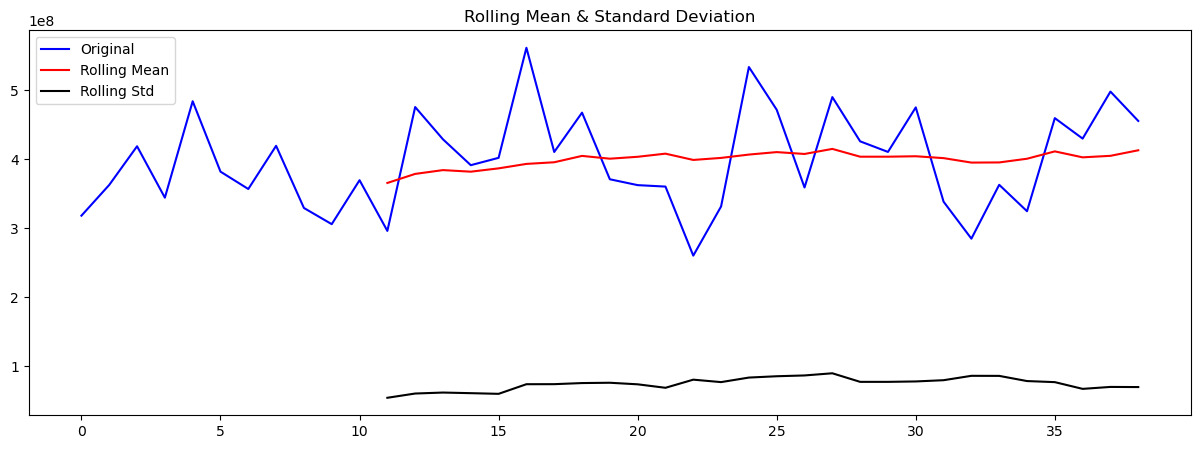

Results of Dickey-Fuller Test:
Test Statistic                -4.14
p-value                        0.00
#Lags Used                     6.00
Number of Observations Used   32.00
Critical Value (1%)           -3.65
Critical Value (5%)           -2.96
Critical Value (10%)          -2.62
dtype: float64


In [44]:
test_stationarity(df_monthly["Total Volume"], 12)

In [46]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

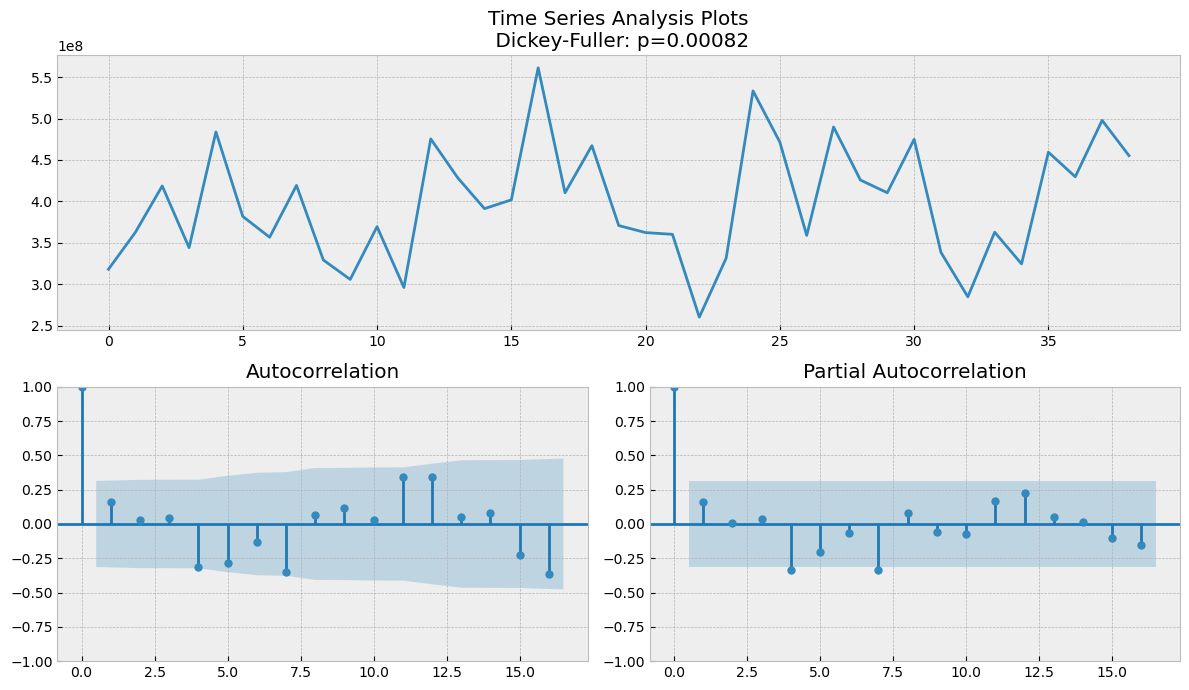

In [48]:
#Plotting log transformed Total volume without differentiation
tsplot(df_monthly["Total Volume"])

In [50]:
data_diff = df_monthly.copy()
data_diff = data_diff.diff().dropna()
len(data_diff)

38

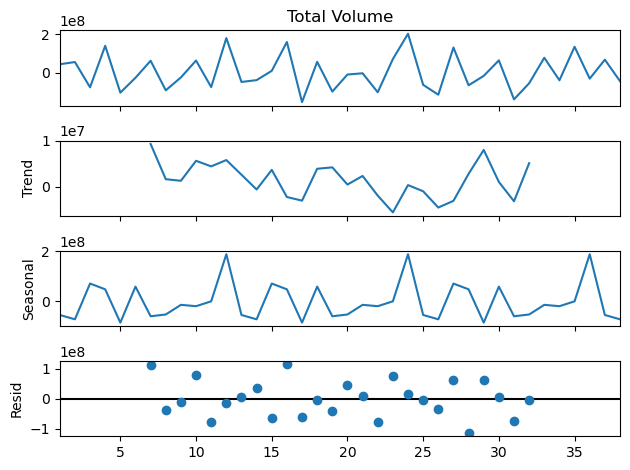

In [52]:
dec = sm.tsa.seasonal_decompose(data_diff['Total Volume'],period = 12).plot()
plt.show()

In [307]:
# import statsmodels

# data_diff = data_diff.asfreq('ME')
# model = statsmodels.tsa.arima.model.ARIMA(data_diff['Total Volume'],order = (1, 1, 1))
# model_fit = model.fit()
# print(model_fit.summary())

In [328]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# data_diff['Total Volume'] = scaler.fit_transform(data_diff[['Total Volume']])

In [ ]:
model = statsmodels.tsa.arima.model.ARIMA(data_diff['Total Volume'], order=(0, 1, 1))  # Simpler model
model_fit = model.fit(method="lbfgs")  # Alternative solver
print(model_fit.summary())

In [62]:
model = statsmodels.tsa.arima.model.ARIMA(data_diff['Total volume log'],order = (0, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       Total volume log   No. Observations:                  168
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 102.884
Date:                Mon, 17 Feb 2025   AIC                           -201.767
Time:                        22:44:19   BIC                           -195.531
Sample:                    01-11-2015   HQIC                          -199.236
                         - 03-25-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0000     40.649     -0.025      0.980     -80.671      78.671
sigma2         0.0166      0.673      0.025      0.980      -1.303       1.336
Ljung-Box (L1) (Q):                  13.03   Jarque-

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [64]:
model = statsmodels.tsa.arima.model.ARIMA(data_diff['Total volume log'],order = (0, 0, 0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       Total volume log   No. Observations:                  168
Model:                          ARIMA   Log Likelihood                 106.578
Date:                Mon, 17 Feb 2025   AIC                           -209.157
Time:                        22:44:19   BIC                           -202.909
Sample:                    01-11-2015   HQIC                          -206.621
                         - 03-25-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.010      0.191      0.849      -0.018       0.022
sigma2         0.0165      0.001     13.547      0.000       0.014       0.019
Ljung-Box (L1) (Q):                  13.48   Jarque-

In [66]:
model = statsmodels.tsa.arima.model.ARIMA(data_diff['Total volume log'],order = (0, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       Total volume log   No. Observations:                  168
Model:                 ARIMA(0, 1, 0)   Log Likelihood                  26.991
Date:                Mon, 17 Feb 2025   AIC                            -51.982
Time:                        22:44:22   BIC                            -48.864
Sample:                    01-11-2015   HQIC                           -50.717
                         - 03-25-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0424      0.003     15.537      0.000       0.037       0.048
Ljung-Box (L1) (Q):                  48.03   Jarque-Bera (JB):               130.50
Prob(Q):                              0.00   Pr

P.S. Как видно в summary, оптимальные значения для SARIMA: (0, 1, 0), И стандартная ошибка в сигмоиде = 0.3; AIC = -51;
Чем меньше эти значения, тем лучше модель.

In [87]:
size = int(len(data) - 30)
train, test = data_diff['Total volume log'][0:size], data_diff['Total volume log'][size:len(data)]

print('ARIMA MODEL: In-Sample Forecasting \n')

history = [x for x in train]
predictions = []

for t in range(len(test)):

    model = statsmodels.tsa.arima.model.ARIMA(history, order=(0, 1, 0))

    model_fit = model.fit(method='nm', maxiter=200, disp=False)


    output = model_fit.forecast(steps = 10)
    yhat = output[0]
    predictions.append(float(yhat))

    obs = test[t]
    history.append(obs)

    print('predicted = %f, expected = %f' % (yhat, obs))



/opt/anaconda3/lib/python3.12/site-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_fini

In [71]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

error = np.sqrt(mean_squared_error(test,predictions))
mape = mean_absolute_percentage_error(test,predictions)
r2score = r2_score(test,predictions)

print('Test RMSE: %.4f' % error)
print('Test MAPE: %.4f' % mape)
print('Test R^2 Score: %.4f' % r2score)

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.